In [1]:
# Import initial 3rd party libraries
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import json

# Configure Notebook
# %matplotlib inline
plt.style.use('fivethirtyeight')
sns.set_context("notebook")
import warnings
warnings.filterwarnings('ignore')

c:\python3_12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
# Load the metadata
data_path = "../../datasets/input/"
df_meta = pd.read_csv(data_path+"movies_metadata.csv")
df_meta = df_meta[["id", "title"]]
df_meta["id"] = pd.to_numeric(df_meta["id"], errors="coerce") 
df_meta = df_meta.dropna(subset=["id"]).astype({"id": int}) 
df_meta = df_meta.dropna(subset=["title"]) 
df_meta = df_meta.drop_duplicates(subset=['id'],keep='first')

# Load the metadata
df_ratings = pd.read_csv(data_path+"ratings_small.csv")
df_ratings = df_ratings[["userId", "movieId", "rating"]]
df_ratings = df_ratings.dropna(subset=["userId", "movieId", "rating"])
df_ratings["userId"] = df_ratings["userId"].astype(int) 
df_ratings["movieId"] = df_ratings["movieId"].astype(int) 
df_ratings["rating"] = df_ratings["rating"].astype(float) 
# If there are duplicate <userId, movieId> pairs, average them. Unlikely tho 
df_ratings = df_ratings.groupby(["userId", "movieId"], as_index=False)["rating"].mean()


df_links = pd.read_csv(data_path+"links_small.csv") 
df_links = df_links[["movieId", "tmdbId"]]
df_links["tmdbId"] = pd.to_numeric(df_links["tmdbId"], errors="coerce") 
df_links = df_links.dropna(subset=["tmdbId"]).astype({"tmdbId": int}) 

In [28]:
# Filter users who have rated too many or too few movies
print("="*50)
print("FILTERING USERS")
print("="*50)

# Count how many movies each user has rated
user_movie_counts = df_ratings['userId'].value_counts()
print(f"User rating counts - Min: {user_movie_counts.min()}, Max: {user_movie_counts.max()}")

# Remove users who have rated less than 5 movies
min_user_ratings = 5
users_to_keep = user_movie_counts[user_movie_counts >= min_user_ratings].index
print(f"Users with at least {min_user_ratings} ratings: {len(users_to_keep)} out of {len(user_movie_counts)}")

# Remove users who rated too many movies (top 5% - these might be bots or very active users)
max_percentile = 95
max_user_ratings = np.percentile(user_movie_counts, max_percentile)
users_to_keep = users_to_keep[user_movie_counts[users_to_keep] <= max_user_ratings]
print(f"Users after removing top 5% (>{max_user_ratings:.0f} ratings): {len(users_to_keep)}")

# Filter the dataset to keep only selected users
ratings_filtered = df_ratings[df_ratings['userId'].isin(users_to_keep)].copy()
print(f"Ratings after user filtering: {ratings_filtered.shape}")


FILTERING USERS
User rating counts - Min: 20, Max: 2391
Users with at least 5 ratings: 671 out of 671
Users after removing top 5% (>520 ratings): 637
Ratings after user filtering: (67995, 3)


In [29]:
# Filter movies with less than 10 ratings

print("="*50)
print("STEP 2: FILTERING MOVIES")
print("="*50)

# Count how many ratings each movie has received
movie_rating_counts = ratings_filtered['movieId'].value_counts()
print(f"Movie rating counts - Min: {movie_rating_counts.min()}, Max: {movie_rating_counts.max()}")

# Keep only movies with at least 20 ratings
min_movie_ratings = 20
movies_to_keep = movie_rating_counts[movie_rating_counts >= min_movie_ratings].index
print(f"Movies with at least {min_movie_ratings} ratings: {len(movies_to_keep)} out of {len(movie_rating_counts)}")

# Filter the dataset to keep only selected movies
ratings_final = ratings_filtered[ratings_filtered['movieId'].isin(movies_to_keep)].copy()
print(f"Final ratings shape: {ratings_final.shape}")


STEP 2: FILTERING MOVIES
Movie rating counts - Min: 1, Max: 308
Movies with at least 20 ratings: 846 out of 6800
Final ratings shape: (44920, 3)


In [30]:
# Create index mappings
print("="*50)
print("STEP 3: CREATING INDEX MAPPINGS")
print("="*50)

unique_users = sorted(ratings_final['userId'].unique())
unique_movies = sorted(ratings_final['movieId'].unique())

print(f"Final number of users: {len(unique_users)}")
print(f"Final number of movies: {len(unique_movies)}")

user_id_to_index = {user_id: idx for idx, user_id in enumerate(unique_users)}
index_to_user_id = {idx: user_id for user_id, idx in user_id_to_index.items()}
movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(unique_movies)}
index_to_movie_id = {idx: movie_id for movie_id, idx in movie_id_to_index.items()}

ratings_final['user_idx'] = ratings_final['userId'].map(user_id_to_index)
ratings_final['movie_idx'] = ratings_final['movieId'].map(movie_id_to_index)

print("Index mappings created successfully!")

STEP 3: CREATING INDEX MAPPINGS
Final number of users: 637
Final number of movies: 846
Index mappings created successfully!


In [31]:
# Create the user-movie rating matrix
print("="*50)
print("STEP 4: CREATING USER-MOVIE MATRIX")
print("="*50)

from scipy.sparse import csr_matrix

n_users = len(unique_users)
n_movies = len(unique_movies)

# Convert to numpy arrays for faster indexing
user_indices = ratings_final['user_idx'].values.astype(int)
movie_indices = ratings_final['movie_idx'].values.astype(int)
rating_values = ratings_final['rating'].values.astype(float)

# Create a sparse user-movie matrix using csr_matrix
# Data, (row_indices, col_indices)
user_movie_matrix = csr_matrix((rating_values, (user_indices, movie_indices)), shape=(n_users, n_movies))

print(f"User-movie matrix shape: {user_movie_matrix.shape}")
# Sparsity for csr_matrix can be calculated as 1 - (number of stored elements / total possible elements)
print(f"Matrix sparsity: {(1 - user_movie_matrix.nnz / (n_users * n_movies)) * 100:.2f}%")

STEP 4: CREATING USER-MOVIE MATRIX
User-movie matrix shape: (637, 846)
Matrix sparsity: 91.66%


In [57]:
from surprise import Dataset, Reader, accuracy
from surprise.model_selection import cross_validate, train_test_split, PredefinedKFold, GridSearchCV
from surprise import SVD, NMF, CoClustering, KNNBasic, KNNWithMeans, KNNWithZScore, SlopeOne
import pandas as pd
import numpy as np



In [58]:
print("Loading data into Surprise format...")
# A Reader is needed to parse the dataset. The rating_scale parameter is important.
reader = Reader(rating_scale=(0.5, 5.0))

# The ratings_final DataFrame already has 'userId', 'movieId', 'rating' columns
# which is perfect for Surprise.

# Convert the ratings_final DataFrame into Surprise's Dataset format
data = Dataset.load_from_df(ratings_final[['userId', 'movieId', 'rating']], reader)

print("Data loaded successfully into Surprise Dataset.")


Loading data into Surprise format...
Data loaded successfully into Surprise Dataset.


In [71]:
# SVD

algo=svd= SVD()
svd_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)


Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8603  0.8753  0.8711  0.8535  0.8746  0.8670  0.0086  
MAE (testset)     0.6579  0.6685  0.6657  0.6473  0.6677  0.6614  0.0080  
Fit time          0.12    0.12    0.12    0.13    0.13    0.12    0.00    
Test time         0.02    0.02    0.02    0.02    0.02    0.02    0.00    


In [72]:
# Non-negative Matrix Factorization
# Similar to SVD

algo=nmf = NMF()
nmf_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Evaluating RMSE, MAE of algorithm NMF on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8881  0.8900  0.8948  0.8960  0.9110  0.8960  0.0080  
MAE (testset)     0.6775  0.6788  0.6829  0.6822  0.6940  0.6831  0.0058  
Fit time          0.23    0.20    0.20    0.20    0.20    0.20    0.01    
Test time         0.01    0.02    0.85    0.02    0.01    0.18    0.34    


In [79]:
# User based kNN

algo=kNNBasic_user= KNNBasic(sim_options={'user_based': True})
kNNBasicUser_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8961  0.9213  0.8861  0.9061  0.9168  0.9053  0.0130  
MAE (testset)     0.6815  0.7025  0.6782  0.6881  0.6925  0.6886  0.0086  
Fit time          0.05    0.04    0.04    0.04    0.04    0.04    0.00    
Test time         0.21    0.23    0.21    0.20    0.21    0.21    0.01    


In [80]:
# Item based kNN

algo=kNNBasic_item= KNNBasic(sim_options={'user_based': False})
kNNBasicItem_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8964  0.8920  0.8976  0.8948  0.8788  0.8919  0.0068  
MAE (testset)     0.6868  0.6830  0.6858  0.6838  0.6747  0.6828  0.0043  
Fit time          0.06    0.06    0.06    0.06    0.05    0.06    0.00    
Test time         0.28    1.12    0.29    0.29    0.28    0.45    0.33    


In [ ]:
# User based kNN taking into account the mean ratings of each user

algo = kNNWithMeans_user= KNNWithMeans(sim_options={'user_based': True})
kNNMeansUser_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNWithMeans on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8674  0.8571  0.8684  0.8774  0.8696  0.8680  0.0065  
MAE (testset)     0.6633  0.6522  0.6620  0.6662  0.6571  0.6602  0.0049  
Fit time          0.05    0.05    0.06    0.05    0.05    0.05    0.00    
Test time         0.24    0.24    0.26    0.23    0.24    0.24    0.01    


In [82]:
# Item based kNN taking into account the mean ratings of each user

algo=kNNWithMeans_item= KNNWithMeans(sim_options={'user_based': False})
kNNMeansItem_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNWithMeans on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8501  0.8572  0.8472  0.8616  0.8708  0.8574  0.0084  
MAE (testset)     0.6488  0.6510  0.6500  0.6556  0.6552  0.6521  0.0028  
Fit time          0.06    0.06    0.06    0.06    0.06    0.06    0.00    
Test time         0.31    0.29    0.31    0.32    0.30    0.31    0.01    


In [ ]:
# User based kNN taking into account the z-score normalization of each user

algo=kNNWithZScore_user= KNNWithZScore(sim_options={'user_based': True})
kNNzUser_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNWithZScore on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8726  0.8689  0.8680  0.8614  0.8811  0.8704  0.0065  
MAE (testset)     0.6574  0.6591  0.6550  0.6532  0.6708  0.6591  0.0062  
Fit time          0.05    0.06    0.05    0.06    0.06    0.06    0.00    
Test time         0.25    0.26    0.25    0.25    0.26    0.25    0.01    


In [84]:
# Item based kNN taking into account the z-score normalization of each user

algo=kNNWithZScore_item= KNNWithZScore(sim_options={'user_based': False})
kNNzItem_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNWithZScore on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8592  0.8866  0.8412  0.8660  0.8538  0.8614  0.0150  
MAE (testset)     0.6500  0.6714  0.6419  0.6595  0.6517  0.6549  0.0100  
Fit time          0.08    0.08    0.08    0.07    0.07    0.07    0.00    
Test time         0.35    0.34    0.33    0.34    0.33    0.34    0.01    


In [85]:
# SlopeOne

algo=slopeOne= SlopeOne()
slope_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Evaluating RMSE, MAE of algorithm SlopeOne on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8513  0.8672  0.8669  0.8768  0.8706  0.8665  0.0084  
MAE (testset)     0.6518  0.6597  0.6596  0.6658  0.6589  0.6592  0.0044  
Fit time          0.06    0.10    0.06    0.06    0.06    0.07    0.02    
Test time         0.19    0.20    0.16    0.16    0.19    0.18    0.02    


In [86]:
# CoClustering

algo=coClustering= CoClustering()
co_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Evaluating RMSE, MAE of algorithm CoClustering on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9012  0.9140  0.9042  0.9193  0.9022  0.9082  0.0072  
MAE (testset)     0.7006  0.7067  0.7030  0.7133  0.7029  0.7053  0.0045  
Fit time          0.23    0.23    0.22    0.22    0.22    0.22    0.01    
Test time         0.01    0.01    0.01    0.01    0.01    0.01    0.00    


In [100]:
# Tuning

# SVD
# grid search
print("SVD Grid Search")

param_grid = {
    "n_factors":[50,100,150,200],
    "n_epochs": [5, 10, 15, 20, 25,30], 
    "lr_all": [0.002, 0.005, 0.007]
    }

grid_search = GridSearchCV(SVD, param_grid, measures=["rmse"], cv=3)
grid_search.fit(data)
svd_algo = grid_search.best_estimator["rmse"]
# algo.fit(data.build_full_trainset())

svd_results_df = pd.DataFrame.from_dict(grid_search.cv_results)
svd_results_df.head()


SVD Grid Search


,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_n_factors,param_n_epochs,param_lr_all
0,0.910396,0.905721,0.911726,0.909281,0.002575,69,0.027548,0.004156,0.032683,0.007304,"{'n_factors': 50, 'n_epochs': 5, 'lr_all': 0.002}",50,5,0.002
1,0.881794,0.877481,0.885383,0.881553,0.003230,55,0.019185,0.001026,0.026322,0.000628,"{'n_factors': 50, 'n_epochs': 5, 'lr_all': 0.005}",50,5,0.005
2,0.875897,0.872082,0.879851,0.875943,0.003172,28,0.018129,0.000447,0.064085,0.056658,"{'n_factors': 50, 'n_epochs': 5, 'lr_all': 0.007}",50,5,0.007
3,0.888178,0.882549,0.889565,0.886764,0.003034,63,0.034848,0.001202,0.027032,0.001875,"{'n_factors': 50, 'n_epochs': 10, 'lr_all': 0....",50,10,0.002
4,0.872234,0.868721,0.875217,0.872057,0.002655,11,0.036575,0.003962,0.025868,0.000240,"{'n_factors': 50, 'n_epochs': 10, 'lr_all': 0....",50,10,0.005


In [159]:
svd_results_df.sort_values('mean_test_rmse').head()

,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_n_factors,param_n_epochs,param_lr_all
7,0.867842,0.864215,0.875832,0.869296,0.004853,1,0.050921,0.001302,0.063023,0.052486,"{'n_factors': 50, 'n_epochs': 15, 'lr_all': 0....",50,15,0.005
10,0.866672,0.865894,0.876239,0.869602,0.004704,2,0.064205,0.000184,0.063051,0.050156,"{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0....",50,20,0.005
5,0.869102,0.864976,0.874839,0.869639,0.004045,3,0.035253,0.001709,0.065137,0.054632,"{'n_factors': 50, 'n_epochs': 10, 'lr_all': 0....",50,10,0.007
8,0.868215,0.865221,0.876444,0.869960,0.004745,4,0.051901,0.001655,0.027443,0.001814,"{'n_factors': 50, 'n_epochs': 15, 'lr_all': 0....",50,15,0.007
11,0.867247,0.866528,0.876353,0.870043,0.004471,5,0.066556,0.000812,0.026120,0.000938,"{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0....",50,20,0.007


<Axes: xlabel='param_n_factors', ylabel='mean_test_rmse'>

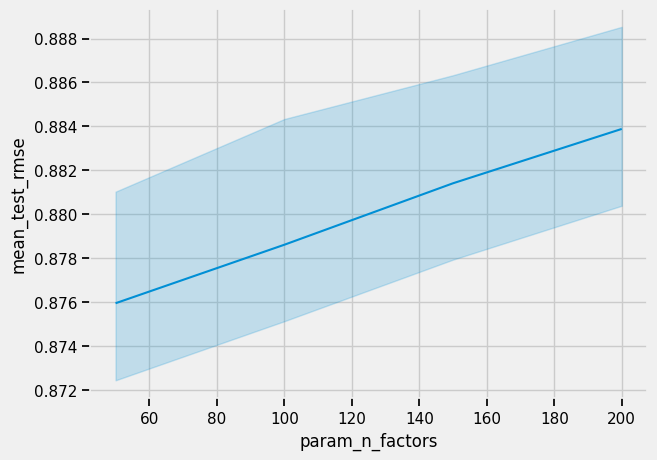

In [112]:
sns.lineplot(svd_results_df,x='param_n_factors', y='mean_test_rmse')

<Axes: xlabel='param_n_epochs', ylabel='mean_test_rmse'>

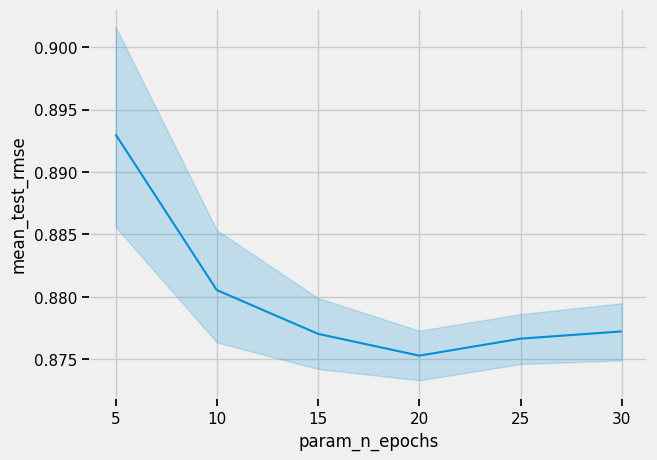

In [113]:
sns.lineplot(svd_results_df,x='param_n_epochs', y='mean_test_rmse')

<Axes: xlabel='param_lr_all', ylabel='mean_test_rmse'>

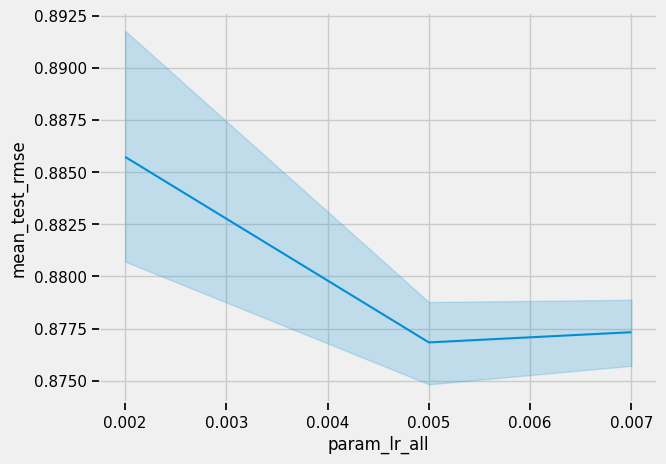

In [114]:
sns.lineplot(svd_results_df,x='param_lr_all', y='mean_test_rmse')

In [101]:
# NMF
# grid search
print("NMF Grid Search")

param_grid = {
    "n_factors":[5,10,15,20,25],
    "n_epochs": [25, 50, 75, 100]
    }

grid_search = GridSearchCV(NMF, param_grid, measures=["rmse"], cv=3)
grid_search.fit(data)
nmf_algo = grid_search.best_estimator["rmse"]
# algo.fit(data.build_full_trainset())

nmf_results_df = pd.DataFrame.from_dict(grid_search.cv_results)
nmf_results_df.head()


NMF Grid Search


,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_n_factors,param_n_epochs
0,1.366961,1.349348,1.358330,1.358213,0.007191,20,0.067115,0.000410,0.027458,0.001060,"{'n_factors': 5, 'n_epochs': 25}",5,25
1,1.044647,1.033936,1.044828,1.041137,0.005093,18,0.132155,0.011150,0.063788,0.055180,"{'n_factors': 5, 'n_epochs': 50}",5,50
2,0.920227,0.908742,0.921601,0.916857,0.005765,8,0.194840,0.002864,0.024820,0.000616,"{'n_factors': 5, 'n_epochs': 75}",5,75
3,0.923740,0.914500,0.922311,0.920184,0.004061,12,0.253033,0.001421,0.025722,0.001050,"{'n_factors': 5, 'n_epochs': 100}",5,100
4,0.972635,0.965378,0.986500,0.974838,0.008762,16,0.084270,0.003661,0.064747,0.054539,"{'n_factors': 10, 'n_epochs': 25}",10,25


In [160]:
nmf_results_df.sort_values('mean_test_rmse').head()

,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_n_factors,param_n_epochs
19,0.908876,0.894662,0.911481,0.905007,0.007392,1,0.459667,0.018075,0.025801,0.001118,"{'n_factors': 25, 'n_epochs': 100}",25,100
13,0.909981,0.898266,0.910038,0.906095,0.005536,2,0.207748,0.004152,0.027768,0.004247,"{'n_factors': 20, 'n_epochs': 50}",20,50
9,0.907878,0.904892,0.914489,0.909086,0.004010,3,0.177213,0.005263,0.065716,0.051942,"{'n_factors': 15, 'n_epochs': 50}",15,50
15,0.919590,0.906742,0.914804,0.913712,0.005302,4,0.422290,0.007287,0.064149,0.056370,"{'n_factors': 20, 'n_epochs': 100}",20,100
8,0.917251,0.906689,0.919818,0.914586,0.005681,5,0.090462,0.003584,0.024036,0.000409,"{'n_factors': 15, 'n_epochs': 25}",15,25


<Axes: xlabel='param_n_factors', ylabel='mean_test_rmse'>

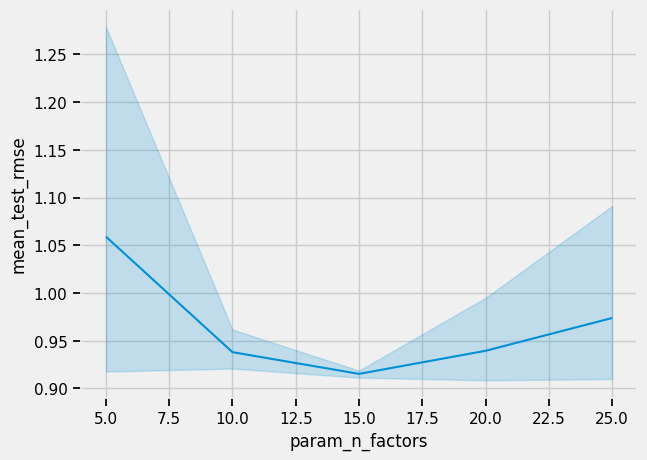

In [119]:
sns.lineplot(nmf_results_df,x='param_n_factors', y='mean_test_rmse')

<Axes: xlabel='param_n_epochs', ylabel='mean_test_rmse'>

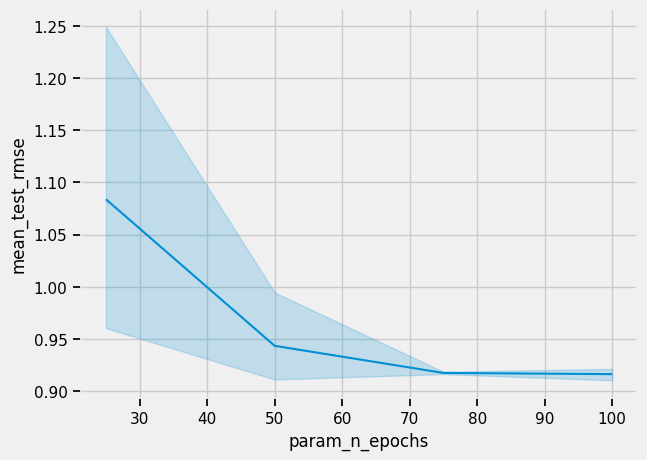

In [120]:
sns.lineplot(nmf_results_df,x='param_n_epochs', y='mean_test_rmse')

In [102]:
# kNN Basic User
# grid search
print("kNN Basic User Grid Search")

param_grid = {

    "k":[20,30,40,60,70],
    "min_k": [1,2,3,4],
    'sim_options': {
        'name': ['msd', 'cosine','pearson'],
        'user_based': [True],
    },
    'verbose':[False]
    }
grid_search = GridSearchCV(KNNBasic, param_grid, measures=["rmse"], cv=3)
grid_search.fit(data)
kNNBasicUser_algo = grid_search.best_estimator["rmse"]
# algo.fit(data.build_full_trainset())

kNNBasicUser_results_df = pd.DataFrame.from_dict(grid_search.cv_results)
kNNBasicUser_results_df.head()

kNN Basic User Grid Search


,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_sim_options,param_verbose
0,0.902734,0.915737,0.910227,0.909566,0.005329,1,0.030003,0.000727,0.320220,0.061611,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'msd', 'user_based': True}",False
1,0.931038,0.945491,0.936781,0.937770,0.005941,37,0.052558,0.001926,0.278494,0.022309,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'cosine', 'user_based': True}",False
2,0.942703,0.956805,0.953655,0.951054,0.006044,60,0.060388,0.001681,0.307747,0.056554,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'pearson', 'user_based': True}",False
3,0.902734,0.915785,0.910220,0.909580,0.005347,2,0.029915,0.002368,0.289722,0.016751,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'msd', 'user_based': True}",False
4,0.931038,0.945537,0.936774,0.937783,0.005962,38,0.056816,0.009482,0.304652,0.029683,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'cosine', 'user_based': True}",False


In [161]:
kNNBasicUser_results_df.sort_values('mean_test_rmse').head()

,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_verbose
0,0.902734,0.915737,0.910227,0.909566,0.005329,1,0.030003,0.000727,0.320220,0.061611,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,False
3,0.902734,0.915785,0.910220,0.909580,0.005347,2,0.029915,0.002368,0.289722,0.016751,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,False
9,0.902954,0.916141,0.909924,0.909673,0.005386,3,0.027838,0.001025,0.248313,0.007519,"{'k': 20, 'min_k': 4, 'sim_options': {'name': ...",20,4,False
6,0.902715,0.916141,0.910220,0.909692,0.005494,4,0.030638,0.002869,0.260032,0.003527,"{'k': 20, 'min_k': 3, 'sim_options': {'name': ...",20,3,False
12,0.903939,0.916769,0.910848,0.910519,0.005243,5,0.029452,0.001624,0.280943,0.016980,"{'k': 30, 'min_k': 1, 'sim_options': {'name': ...",30,1,False


<Axes: xlabel='param_k', ylabel='mean_test_rmse'>

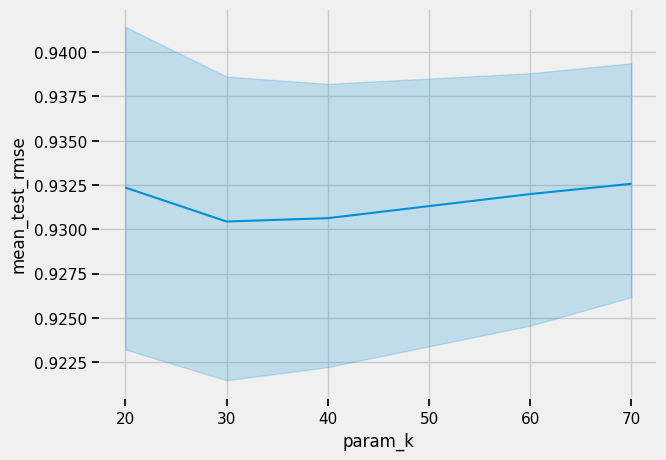

In [121]:
sns.lineplot(kNNBasicUser_results_df,x='param_k', y='mean_test_rmse')

<Axes: xlabel='param_min_k', ylabel='mean_test_rmse'>

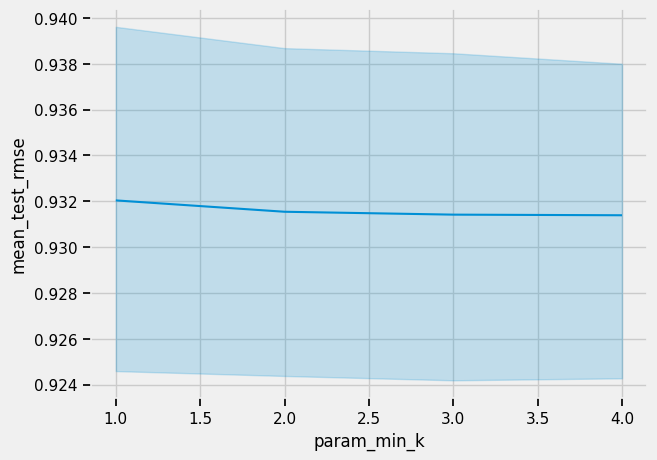

In [125]:
sns.lineplot(kNNBasicUser_results_df,x='param_min_k', y='mean_test_rmse')

In [127]:
kNNBasicUser_results_df2=kNNBasicUser_results_df.join(pd.DataFrame(kNNBasicUser_results_df.pop('param_sim_options').values.tolist()))

<Axes: xlabel='name', ylabel='mean_test_rmse'>

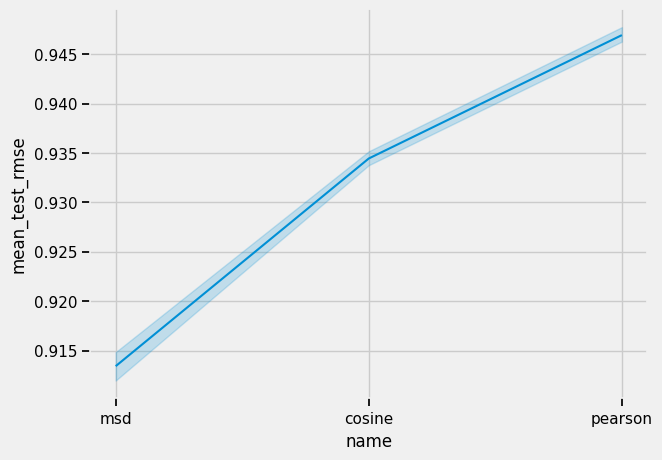

In [130]:
sns.lineplot(kNNBasicUser_results_df2,x='name', y='mean_test_rmse')

In [103]:
# kNN Basic Item
# grid search
print("kNN Basic Item Grid Search")

param_grid = {

    "k":[20,30,40,60,70],
    "min_k": [1,2,3,4],
    'sim_options': {
        'name': ['msd', 'cosine','pearson'],
        'user_based': [False],
    },
    'verbose':[False]
    }
grid_search = GridSearchCV(KNNBasic, param_grid, measures=["rmse"], cv=3)
grid_search.fit(data)
kNNBasicItem_algo = grid_search.best_estimator["rmse"]
# algo.fit(data.build_full_trainset())

kNNBasicItem_results_df = pd.DataFrame.from_dict(grid_search.cv_results)
kNNBasicItem_results_df.head()

kNN Basic Item Grid Search


,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_sim_options,param_verbose
0,0.902371,0.899904,0.902055,0.901443,0.001096,15,0.043078,0.001086,0.375391,0.055163,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'msd', 'user_based': False}",False
1,0.939800,0.935902,0.936403,0.937368,0.001731,58,0.075140,0.003617,0.326470,0.007576,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'cosine', 'user_based': False}",False
2,0.940078,0.936809,0.937888,0.938258,0.001360,60,0.093012,0.008657,0.324973,0.008167,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'pearson', 'user_based': False}",False
3,0.902371,0.899790,0.902066,0.901409,0.001152,14,0.039402,0.000439,0.356300,0.048817,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'msd', 'user_based': False}",False
4,0.939800,0.935792,0.936415,0.937336,0.001761,57,0.076904,0.005730,0.328450,0.011723,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'cosine', 'user_based': False}",False


In [162]:
kNNBasicItem_results_df.sort_values('mean_test_rmse').head()

,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_verbose
21,0.898711,0.895519,0.898624,0.897618,0.001485,1,0.039552,0.001051,0.350342,0.009578,"{'k': 30, 'min_k': 4, 'sim_options': {'name': ...",30,4,False
15,0.899537,0.895095,0.898327,0.897653,0.001875,2,0.039475,0.001109,0.370442,0.005657,"{'k': 30, 'min_k': 2, 'sim_options': {'name': ...",30,2,False
33,0.898884,0.894694,0.899423,0.897667,0.002114,3,0.039024,0.000802,0.425954,0.060246,"{'k': 40, 'min_k': 4, 'sim_options': {'name': ...",40,4,False
12,0.899537,0.895209,0.898315,0.897687,0.001822,4,0.039809,0.000260,0.360643,0.008041,"{'k': 30, 'min_k': 1, 'sim_options': {'name': ...",30,1,False
27,0.899710,0.894269,0.899126,0.897702,0.002439,5,0.038585,0.001751,0.377255,0.001417,"{'k': 40, 'min_k': 2, 'sim_options': {'name': ...",40,2,False


<Axes: xlabel='param_k', ylabel='mean_test_rmse'>

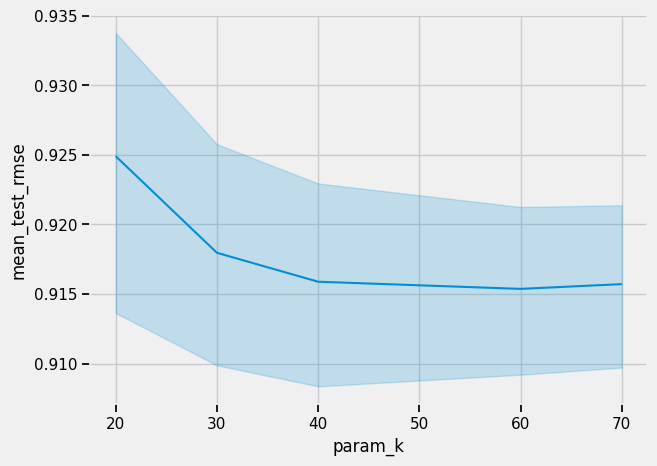

In [131]:
sns.lineplot(kNNBasicItem_results_df,x='param_k', y='mean_test_rmse')

<Axes: xlabel='param_min_k', ylabel='mean_test_rmse'>

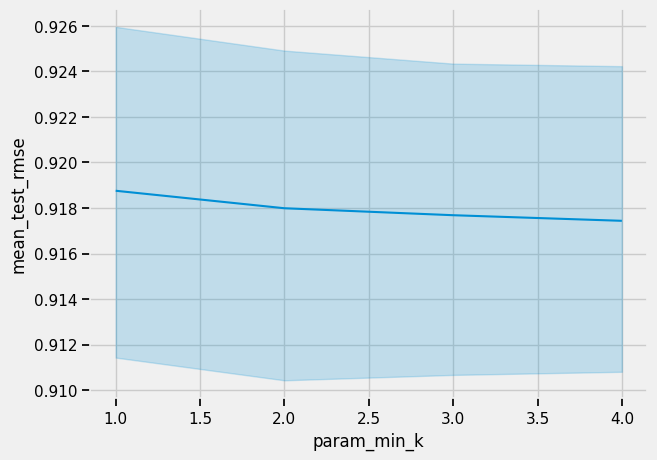

In [132]:
sns.lineplot(kNNBasicItem_results_df,x='param_min_k', y='mean_test_rmse')

In [133]:
kNNBasicItem_results_df2=kNNBasicItem_results_df.join(pd.DataFrame(kNNBasicItem_results_df.pop('param_sim_options').values.tolist()))

<Axes: xlabel='name', ylabel='mean_test_rmse'>

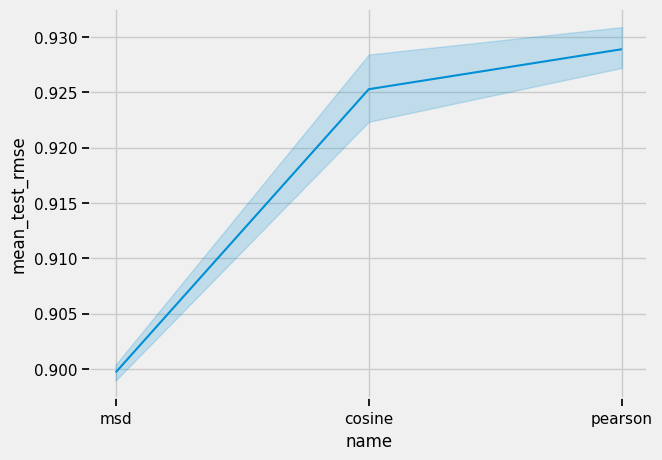

In [134]:
sns.lineplot(kNNBasicItem_results_df2,x='name', y='mean_test_rmse')

In [104]:
# kNN Means User
# grid search
print("kNN Means User Grid Search")

param_grid = {

    "k":[20,30,40,60,70],
    "min_k": [1,2,3,4],
    'sim_options': {
        'name': ['msd', 'cosine','pearson'],
        'user_based': [True],
    },
    'verbose':[False]
    }
grid_search = GridSearchCV(KNNWithMeans, param_grid, measures=["rmse"], cv=3)
grid_search.fit(data)
kNNMeansUser_algo = grid_search.best_estimator["rmse"]
# algo.fit(data.build_full_trainset())

kNNMeansUser_results_df = pd.DataFrame.from_dict(grid_search.cv_results)
kNNMeansUser_results_df.head()

kNN Means User Grid Search


,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_sim_options,param_verbose
0,0.877243,0.882861,0.874231,0.878112,0.003576,34,0.033329,0.003435,0.314744,0.065201,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'msd', 'user_based': True}",False
1,0.881662,0.885797,0.877589,0.881682,0.003351,38,0.053314,0.001679,0.287268,0.020334,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'cosine', 'user_based': True}",False
2,0.889362,0.895519,0.885237,0.890039,0.004225,60,0.060532,0.002237,0.308898,0.051660,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'pearson', 'user_based': True}",False
3,0.877243,0.882786,0.874232,0.878087,0.003543,33,0.033393,0.000595,0.277616,0.001824,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'msd', 'user_based': True}",False
4,0.881662,0.885722,0.877590,0.881658,0.003320,37,0.052943,0.002324,0.279439,0.006093,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'cosine', 'user_based': True}",False


In [163]:
kNNMeansUser_results_df.sort_values('mean_test_rmse').head()

,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_verbose
39,0.874447,0.879698,0.869561,0.874569,0.004140,1,0.033257,0.000987,0.393101,0.011458,"{'k': 60, 'min_k': 2, 'sim_options': {'name': ...",60,2,False
36,0.874447,0.879774,0.869560,0.874593,0.004171,2,0.033941,0.000900,0.391716,0.009466,"{'k': 60, 'min_k': 1, 'sim_options': {'name': ...",60,1,False
45,0.874472,0.879651,0.869678,0.874600,0.004073,3,0.037035,0.003940,0.384845,0.006935,"{'k': 60, 'min_k': 4, 'sim_options': {'name': ...",60,4,False
42,0.874563,0.879698,0.869565,0.874609,0.004137,4,0.037272,0.003015,0.407524,0.009649,"{'k': 60, 'min_k': 3, 'sim_options': {'name': ...",60,3,False
27,0.874807,0.879515,0.869519,0.874614,0.004083,5,0.037061,0.001481,0.441961,0.055476,"{'k': 40, 'min_k': 2, 'sim_options': {'name': ...",40,2,False


<Axes: xlabel='param_k', ylabel='mean_test_rmse'>

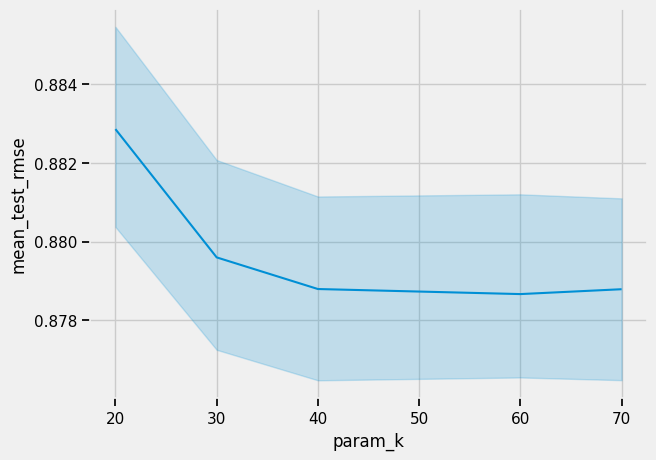

In [135]:
sns.lineplot(kNNMeansUser_results_df,x='param_k', y='mean_test_rmse')

<Axes: xlabel='param_min_k', ylabel='mean_test_rmse'>

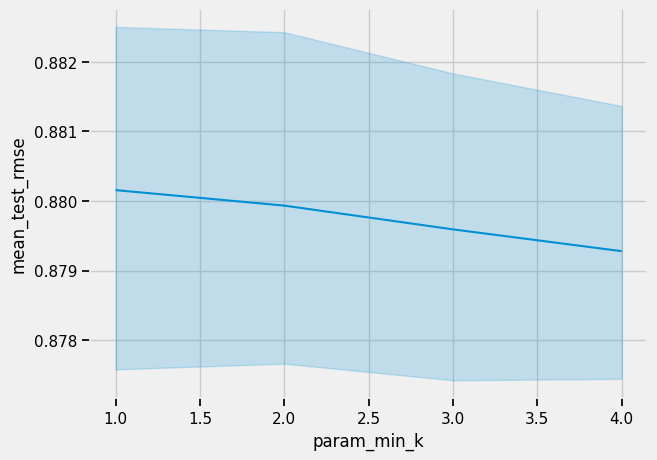

In [136]:
sns.lineplot(kNNMeansUser_results_df,x='param_min_k', y='mean_test_rmse')

In [137]:
kNNMeansUser_results_df2=kNNMeansUser_results_df.join(pd.DataFrame(kNNMeansUser_results_df.pop('param_sim_options').values.tolist()))

<Axes: xlabel='name', ylabel='mean_test_rmse'>

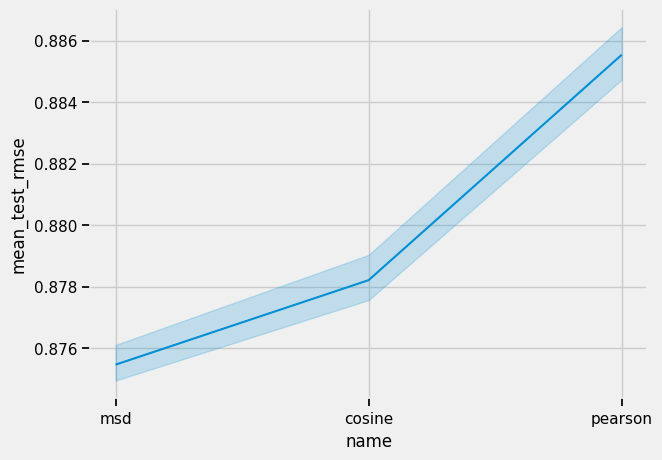

In [138]:
sns.lineplot(kNNMeansUser_results_df2,x='name', y='mean_test_rmse')

In [105]:
# kNN Means Item
# grid search
print("kNN Means Item Grid Search")

param_grid = {

    "k":[20,30,40,60,70],
    "min_k": [1,2,3,4],
    'sim_options': {
        'name': ['msd', 'cosine','pearson'],
        'user_based': [False],
    },
    'verbose':[False]
    }
grid_search = GridSearchCV(KNNWithMeans, param_grid, measures=["rmse"], cv=3)
grid_search.fit(data)
kNNMeansItem_algo = grid_search.best_estimator["rmse"]
# algo.fit(data.build_full_trainset())

kNNMeansItem_results_df = pd.DataFrame.from_dict(grid_search.cv_results)
kNNMeansItem_results_df.head()

kNN Means Item Grid Search


,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_sim_options,param_verbose
0,0.872220,0.868439,0.869048,0.869902,0.001657,29,0.057186,0.002965,0.488668,0.053182,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'msd', 'user_based': False}",False
1,0.879867,0.877917,0.879381,0.879055,0.000829,55,0.095468,0.006814,0.404120,0.009512,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'cosine', 'user_based': False}",False
2,0.882282,0.875906,0.881053,0.879747,0.002762,60,0.111894,0.002665,0.465361,0.059869,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'pearson', 'user_based': False}",False
3,0.872660,0.868444,0.868779,0.869961,0.001913,30,0.047881,0.004148,0.382555,0.012086,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'msd', 'user_based': False}",False
4,0.880304,0.877922,0.879116,0.879114,0.000972,56,0.083754,0.003294,0.396825,0.026006,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'cosine', 'user_based': False}",False


In [164]:
kNNMeansItem_results_df.sort_values('mean_test_rmse').head()

,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_verbose
36,0.865055,0.860691,0.864128,0.863291,0.001877,1,0.046737,0.000747,0.597354,0.073103,"{'k': 60, 'min_k': 1, 'sim_options': {'name': ...",60,1,False
39,0.865499,0.860697,0.863858,0.863351,0.001993,2,0.051113,0.006061,0.591310,0.053800,"{'k': 60, 'min_k': 2, 'sim_options': {'name': ...",60,2,False
45,0.865170,0.860926,0.864205,0.863434,0.001816,3,0.053363,0.005518,0.566525,0.013610,"{'k': 60, 'min_k': 4, 'sim_options': {'name': ...",60,4,False
48,0.865286,0.860821,0.864204,0.863437,0.001902,4,0.049438,0.001324,0.592035,0.024829,"{'k': 70, 'min_k': 1, 'sim_options': {'name': ...",70,1,False
42,0.865290,0.860909,0.864212,0.863470,0.001864,5,0.051311,0.003633,0.599003,0.033478,"{'k': 60, 'min_k': 3, 'sim_options': {'name': ...",60,3,False


<Axes: xlabel='param_k', ylabel='mean_test_rmse'>

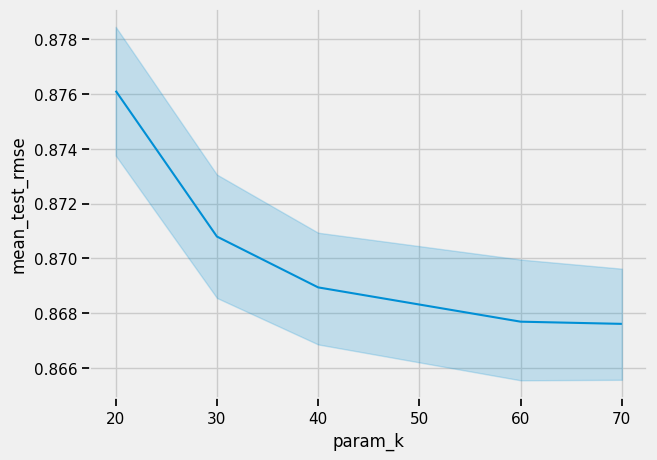

In [139]:
sns.lineplot(kNNMeansItem_results_df,x='param_k', y='mean_test_rmse')

<Axes: xlabel='param_min_k', ylabel='mean_test_rmse'>

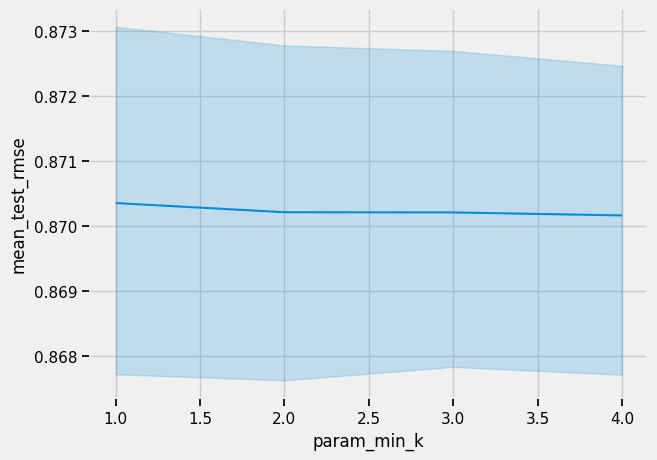

In [140]:
sns.lineplot(kNNMeansItem_results_df,x='param_min_k', y='mean_test_rmse')

In [141]:
kNNMeansItem_results_df2=kNNMeansItem_results_df.join(pd.DataFrame(kNNMeansItem_results_df.pop('param_sim_options').values.tolist()))

<Axes: xlabel='name', ylabel='mean_test_rmse'>

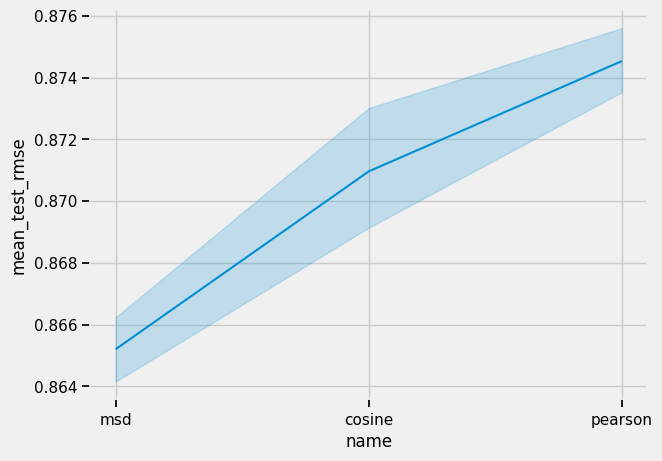

In [142]:
sns.lineplot(kNNMeansItem_results_df2,x='name', y='mean_test_rmse')

In [106]:
# kNN Z User
# grid search
print("kNN Z User Grid Search")

param_grid = {

    "k":[20,30,40,60,70],
    "min_k": [1,2,3,4],
    'sim_options': {
        'name': ['msd', 'cosine','pearson'],
        'user_based': [True],
    },
    'verbose':[False]
    }
grid_search = GridSearchCV(KNNWithZScore, param_grid, measures=["rmse"], cv=3)
grid_search.fit(data)
kNNzUser_algo = grid_search.best_estimator["rmse"]
# algo.fit(data.build_full_trainset())

kNNzUser_results_df = pd.DataFrame.from_dict(grid_search.cv_results)
kNNzUser_results_df.head()

kNN Z User Grid Search


,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_sim_options,param_verbose
0,0.883776,0.877642,0.884026,0.881815,0.002952,34,0.049115,0.003309,0.332174,0.019643,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'msd', 'user_based': True}",False
1,0.886195,0.879690,0.886344,0.884076,0.003102,47,0.062398,0.001697,0.374837,0.066178,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'cosine', 'user_based': True}",False
2,0.889330,0.885867,0.892142,0.889113,0.002566,60,0.074704,0.002899,0.307146,0.011985,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'pearson', 'user_based': True}",False
3,0.883778,0.877705,0.884026,0.881837,0.002923,35,0.045972,0.005293,0.343719,0.040229,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'msd', 'user_based': True}",False
4,0.886197,0.879754,0.886344,0.884098,0.003073,48,0.069403,0.004137,0.371285,0.063839,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'cosine', 'user_based': True}",False


In [165]:
kNNzUser_results_df.sort_values('mean_test_rmse').head()

,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_verbose
36,0.878339,0.872484,0.878978,0.876600,0.002923,1,0.047655,0.004816,0.432241,0.006710,"{'k': 60, 'min_k': 1, 'sim_options': {'name': ...",60,1,False
39,0.878342,0.872547,0.878978,0.876623,0.002893,2,0.045406,0.003328,0.438326,0.003685,"{'k': 60, 'min_k': 2, 'sim_options': {'name': ...",60,2,False
42,0.878287,0.872540,0.879073,0.876633,0.002912,3,0.045184,0.001156,0.474016,0.052657,"{'k': 60, 'min_k': 3, 'sim_options': {'name': ...",60,3,False
24,0.878482,0.872916,0.878791,0.876729,0.002700,4,0.048303,0.004604,0.444096,0.048769,"{'k': 40, 'min_k': 1, 'sim_options': {'name': ...",40,1,False
27,0.878485,0.872980,0.878791,0.876752,0.002670,5,0.047910,0.002521,0.412290,0.009888,"{'k': 40, 'min_k': 2, 'sim_options': {'name': ...",40,2,False


<Axes: xlabel='param_k', ylabel='mean_test_rmse'>

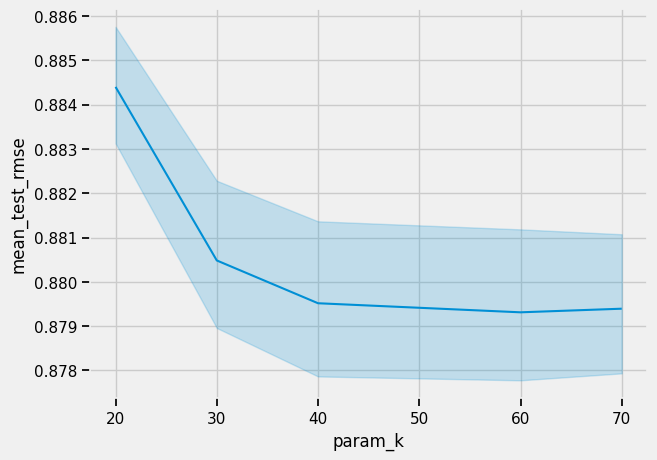

In [143]:
sns.lineplot(kNNzUser_results_df,x='param_k', y='mean_test_rmse')

<Axes: xlabel='param_min_k', ylabel='mean_test_rmse'>

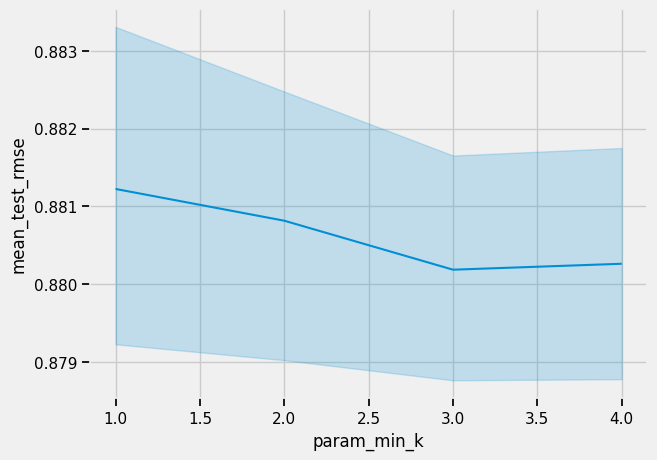

In [144]:
sns.lineplot(kNNzUser_results_df,x='param_min_k', y='mean_test_rmse')

In [145]:
kNNzUser_results_df2=kNNzUser_results_df.join(pd.DataFrame(kNNzUser_results_df.pop('param_sim_options').values.tolist()))

<Axes: xlabel='name', ylabel='mean_test_rmse'>

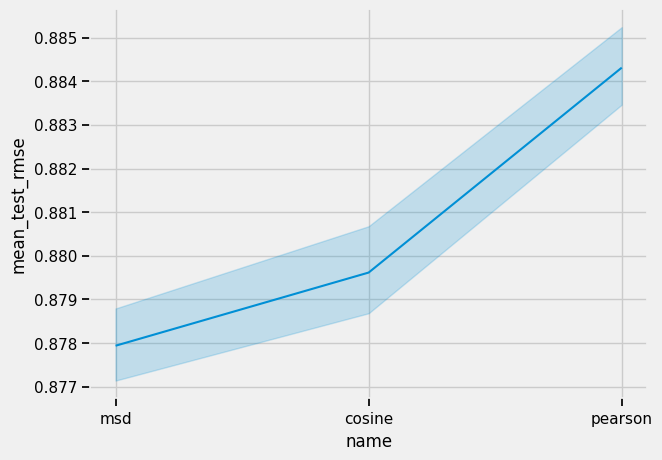

In [146]:
sns.lineplot(kNNzUser_results_df2,x='name', y='mean_test_rmse')

In [107]:
# kNN Z Item
# grid search
print("kNN Z Item Grid Search")

param_grid = {

    "k":[20,30,40,60,70],
    "min_k": [1,2,3,4],
    'sim_options': {
        'name': ['msd', 'cosine','pearson'],
        'user_based': [False],
    },
    'verbose':[False]
    }
grid_search = GridSearchCV(KNNWithZScore, param_grid, measures=["rmse"], cv=3)
grid_search.fit(data)
kNNzItem_algo = grid_search.best_estimator["rmse"]
# algo.fit(data.build_full_trainset())

kNNzItem_results_df = pd.DataFrame.from_dict(grid_search.cv_results)
kNNzItem_results_df.head()

kNN Z Item Grid Search


,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_sim_options,param_verbose
0,0.871541,0.862241,0.878838,0.870873,0.006792,36,0.064970,0.001122,0.478063,0.040747,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'msd', 'user_based': False}",False
1,0.882298,0.872418,0.886114,0.880277,0.005771,60,0.097185,0.001094,0.425430,0.018608,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'cosine', 'user_based': False}",False
2,0.877806,0.868519,0.887987,0.878104,0.007950,56,0.114243,0.001496,0.443331,0.084234,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'pearson', 'user_based': False}",False
3,0.871542,0.862171,0.878838,0.870850,0.006822,35,0.064102,0.006830,0.418935,0.020469,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'msd', 'user_based': False}",False
4,0.882299,0.872349,0.886114,0.880254,0.005802,59,0.109065,0.017218,0.464044,0.035634,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'cosine', 'user_based': False}",False


In [166]:
kNNzItem_results_df.sort_values('mean_test_rmse').head()

,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_verbose
42,0.864560,0.858185,0.871318,0.864688,0.005362,1,0.062050,0.002191,0.619164,0.021223,"{'k': 60, 'min_k': 3, 'sim_options': {'name': ...",60,3,False
39,0.864721,0.858025,0.871493,0.864746,0.005498,2,0.061958,0.002723,0.609852,0.026997,"{'k': 60, 'min_k': 2, 'sim_options': {'name': ...",60,2,False
36,0.864720,0.858095,0.871493,0.864770,0.005470,3,0.066477,0.010826,0.613262,0.018489,"{'k': 60, 'min_k': 1, 'sim_options': {'name': ...",60,1,False
45,0.864225,0.858140,0.871990,0.864785,0.005668,4,0.061519,0.001567,0.601159,0.012519,"{'k': 60, 'min_k': 4, 'sim_options': {'name': ...",60,4,False
54,0.864741,0.858242,0.871431,0.864805,0.005385,5,0.064443,0.001018,0.672352,0.059922,"{'k': 70, 'min_k': 3, 'sim_options': {'name': ...",70,3,False


<Axes: xlabel='param_k', ylabel='mean_test_rmse'>

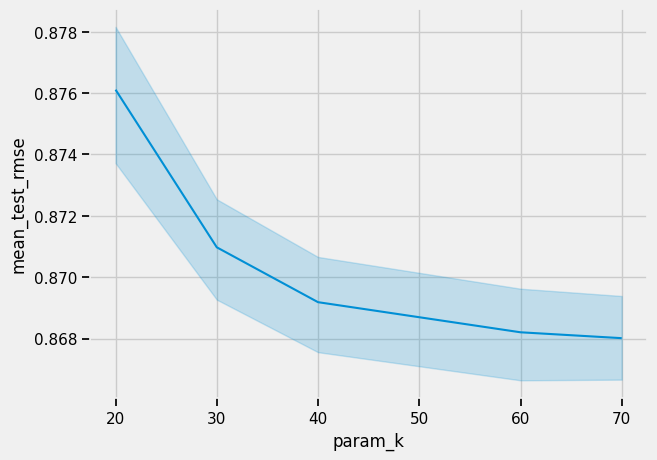

In [147]:
sns.lineplot(kNNzItem_results_df,x='param_k', y='mean_test_rmse')

<Axes: xlabel='param_min_k', ylabel='mean_test_rmse'>

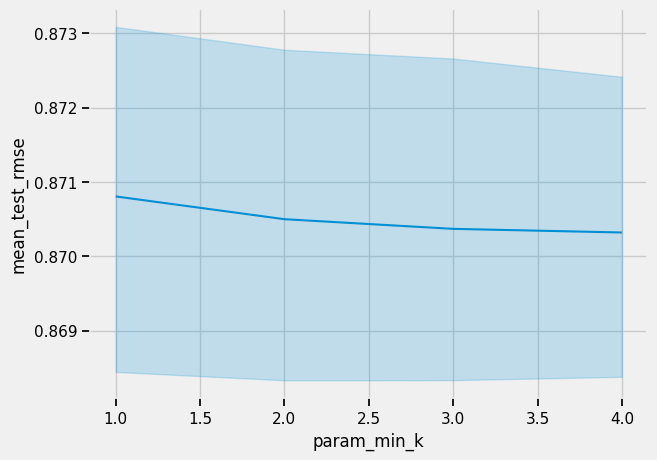

In [148]:
sns.lineplot(kNNzItem_results_df,x='param_min_k', y='mean_test_rmse')

In [149]:
kNNzItem_results_df2=kNNzItem_results_df.join(pd.DataFrame(kNNzItem_results_df.pop('param_sim_options').values.tolist()))

<Axes: xlabel='name', ylabel='mean_test_rmse'>

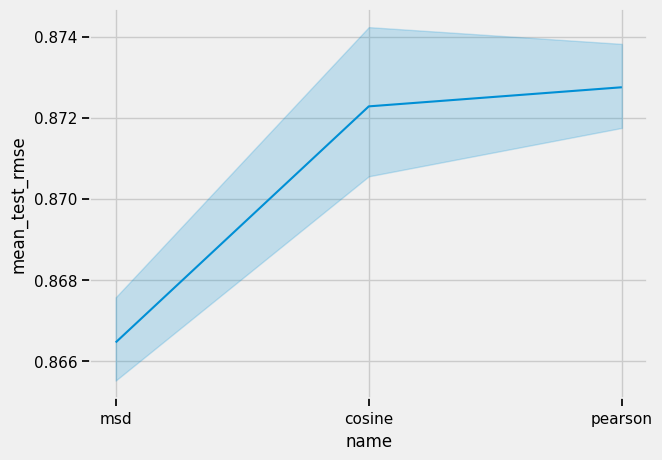

In [150]:
sns.lineplot(kNNzItem_results_df2,x='name', y='mean_test_rmse')

In [154]:
# SlopeOne has no parameters

# Co-Clustering
# grid search
print("kNN Z Item Grid Search")

param_grid = {

    "n_cltr_u":[1,2,3,4],
    "n_cltr_i": [1,2,3,4],
    "n_epochs": [10,15,20,25,30],
    'verbose':[False]
    }
grid_search = GridSearchCV(CoClustering, param_grid, measures=["rmse"], cv=3)
grid_search.fit(data)
algo = grid_search.best_estimator["rmse"]
# algo.fit(data.build_full_trainset())

co_results_df = pd.DataFrame.from_dict(grid_search.cv_results)
co_results_df.head()

kNN Z Item Grid Search


,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_n_cltr_u,param_n_cltr_i,param_n_epochs,param_verbose
0,0.898937,0.901744,0.895545,0.898742,0.002535,1,0.069167,0.000615,0.022291,0.002175,"{'n_cltr_u': 1, 'n_cltr_i': 1, 'n_epochs': 10,...",1,1,10,False
1,0.898937,0.901744,0.895545,0.898742,0.002535,27,0.093960,0.001096,0.020864,0.000838,"{'n_cltr_u': 1, 'n_cltr_i': 1, 'n_epochs': 15,...",1,1,15,False
2,0.898937,0.901744,0.895545,0.898742,0.002535,25,0.127130,0.009199,0.087028,0.093968,"{'n_cltr_u': 1, 'n_cltr_i': 1, 'n_epochs': 20,...",1,1,20,False
3,0.898937,0.901744,0.895545,0.898742,0.002535,24,0.155129,0.003976,0.021926,0.000980,"{'n_cltr_u': 1, 'n_cltr_i': 1, 'n_epochs': 25,...",1,1,25,False
4,0.898937,0.901744,0.895545,0.898742,0.002535,23,0.184733,0.011094,0.021896,0.000613,"{'n_cltr_u': 1, 'n_cltr_i': 1, 'n_epochs': 30,...",1,1,30,False


In [167]:
co_results_df.sort_values('mean_test_rmse').head()

,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_n_cltr_u,param_n_cltr_i,param_n_epochs,param_verbose
0,0.898937,0.901744,0.895545,0.898742,0.002535,1,0.069167,0.000615,0.022291,0.002175,"{'n_cltr_u': 1, 'n_cltr_i': 1, 'n_epochs': 10,...",1,1,10,False
20,0.898937,0.901744,0.895545,0.898742,0.002535,2,0.084473,0.001263,0.098543,0.104497,"{'n_cltr_u': 2, 'n_cltr_i': 1, 'n_epochs': 10,...",2,1,10,False
21,0.898937,0.901744,0.895545,0.898742,0.002535,3,0.134885,0.023250,0.025876,0.002155,"{'n_cltr_u': 2, 'n_cltr_i': 1, 'n_epochs': 15,...",2,1,15,False
22,0.898937,0.901744,0.895545,0.898742,0.002535,4,0.170076,0.012078,0.027091,0.001874,"{'n_cltr_u': 2, 'n_cltr_i': 1, 'n_epochs': 20,...",2,1,20,False
23,0.898937,0.901744,0.895545,0.898742,0.002535,5,0.188931,0.005274,0.023949,0.004227,"{'n_cltr_u': 2, 'n_cltr_i': 1, 'n_epochs': 25,...",2,1,25,False


<Axes: xlabel='param_n_cltr_u', ylabel='mean_test_rmse'>

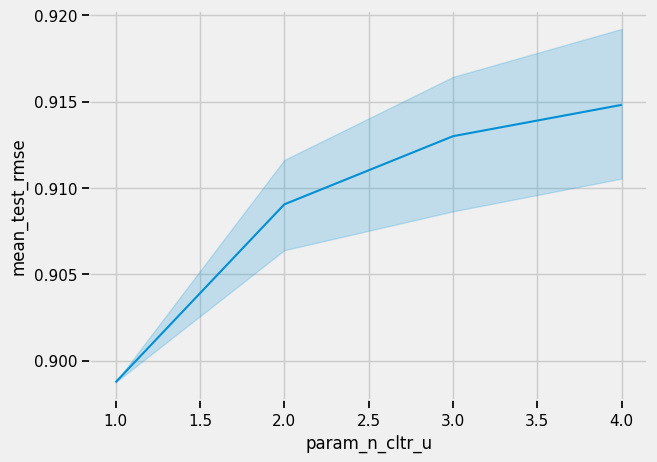

In [155]:
sns.lineplot(co_results_df,x='param_n_cltr_u', y='mean_test_rmse')

<Axes: xlabel='param_n_cltr_i', ylabel='mean_test_rmse'>

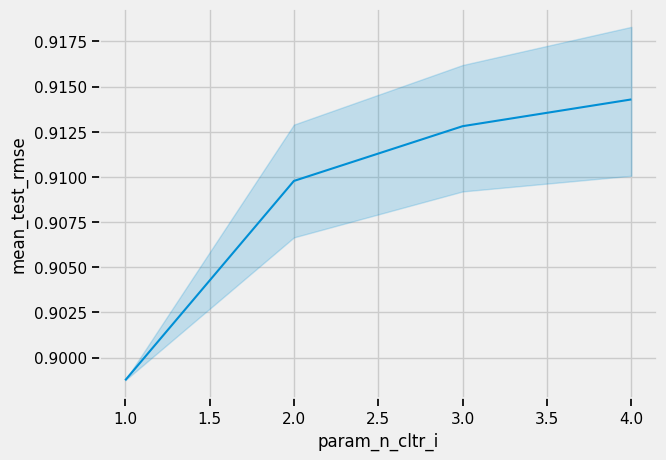

In [156]:
sns.lineplot(co_results_df,x='param_n_cltr_i', y='mean_test_rmse')

<Axes: xlabel='param_n_epochs', ylabel='mean_test_rmse'>

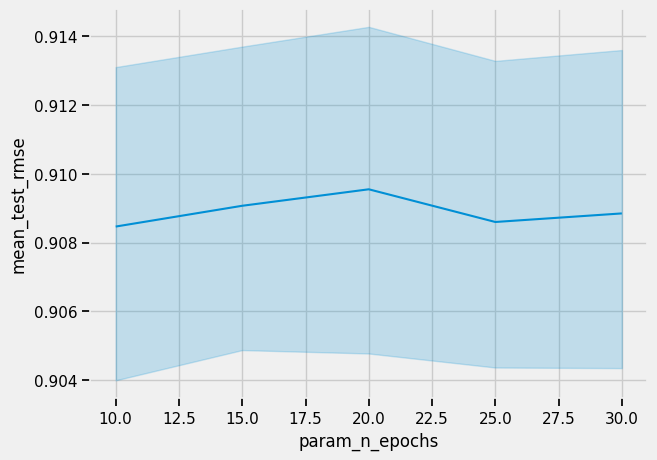

In [157]:
sns.lineplot(co_results_df,x='param_n_epochs', y='mean_test_rmse')